In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

from scripts.utils import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, Dropout ,Input, GlobalAveragePooling2D
from keras.callbacks import TensorBoard, ModelCheckpoint, EarlyStopping
from keras.optimizers import SGD, Adam
from keras import layers
from keras.applications import ResNet50

mixed_precision.set_global_policy("mixed_float16")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

2026-03-04 21:00:13.413532: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-04 21:00:13.582917: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# directory where images are located
data_dir = "../data/original"
image_size = (96, 96)
batch_size = 128

file_paths = []
labels = []

# the name of each folder corresponds to the label of the images within
class_names = os.listdir(data_dir)
class_to_index = {name: i for i, name in enumerate(class_names)}

# for each folder, we'll save the path of each file with its correspondent label
for class_name in class_names:
    class_dir = f"{data_dir}/{class_name}"
    images = sorted(os.listdir(class_dir))
    for img_path in images:
        file_paths.append(class_dir + "/" + str(img_path))
        labels.append(class_to_index[class_name])

# now we have all the paths and labels together
file_paths = np.array(file_paths)

# bad_files = []

# for path in file_paths:
#     try:
#         if not check_jpeg(path):
#             bad_files.append(path)
#     except:
#         bad_files.append(path)

# print("invalid files:" +  str(len(bad_files)))

# todo: include if

# fix bad_files (already done)
# for path in bad_files:
#     img = Image.open(path)
#     new_path = path.rsplit(".", 1)[0] + ".jpg"
#     img.convert("RGB").save(new_path, "JPEG")

In [3]:
labels = np.array(labels)
dimension = 3

X_train, X_test, y_train, y_test = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

X_train_full, y_train_full = load_full_dataset(X_train, y_train)
X_train_full = X_train_full.numpy().astype(int).squeeze()
y_train_labels = np.argmax(y_train_full.numpy(), axis = 1)

X_test_full, y_test_full = load_full_dataset(X_test, y_test)
X_test_full = X_test_full.numpy().astype(int).squeeze()
y_test_labels = np.argmax(y_test_full.numpy(), axis = 1)


I0000 00:00:1772654416.623150    1516 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5563 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2026-03-04 21:00:19.837060: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-04 21:00:22.623681: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [4]:
class_weights = dict(enumerate(class_weights))

## Baseline

In [8]:
def build_baseline_model(n_filters = 64, n_neurons = 64, learning_rate = 1e-2, momentum = 0.0, 
                      kernel_size = 3, pool_size = 2, sparse = True, **kwargs):
    '''Builds the first CNN architecture. This model is intended to be very simple, to start understanding how well it performs over the dataset
        and to start developing more complex models. It uses basic concepts of CNNs: a convolution layer followed by a pooling layer, then a dense layer with a final
        softmax given output.
        
    Args:
        - n_filters (int): number of filters to be used on convolution layers (Conv2D). Default set to 64.
        - n_neurons (int): number of neurons to be used on dense layers (Dense). Default set to 64.
        - learning_rate (float): indicates a which rate the gradient moves. Default set to 1e-2.
        - momentum (float): proportion regarding how much of past gradients affect the current gradient step. Default set to 0.0.
        - kernel_size (int): indicates the size of the squared sliding window over the feature map. Default set to 3.
        - pool_size (int): indicated the size of the downsample pooling window. Default set to 2.
        - sparse (bool): sets if labels should be considered as one-hot (False) or integers (True). Default set to True.
        - other parameters such as activation function (ReLU), padding (same) and activation (softmax) were kept as default throught all architectures.
    Returns:
        - model: fully compiled model with all respective features.
    
    '''
    
    normalization_layer = Rescaling(1./255)
    
    model = Sequential([
    Input(shape = (image_size[0], image_size[1], dimension)),
    normalization_layer,
    Conv2D(n_filters, kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    GlobalAveragePooling2D(),
    Dense(n_neurons, activation="relu"),
    Dense(10, activation = "softmax")
                    ])
    
    # for the first model only SGD optimizer is used.
    optimizer = SGD(learning_rate=learning_rate, momentum=momentum)
    
    loss = "categorical_crossentropy"
    if sparse:
        loss = "sparse_categorical_crossentropy"
    model.compile(loss = loss,
        optimizer = optimizer,
        metrics = ["accuracy"])
    
    return model

In [6]:
which_arch = "baseline"

param_grid = {"learning_rate": [1e-2, 1e-3],
              "momentum": [0.0, 0.9],
              "kernel_size": [2,3],
              "n_filters": [32, 64],
              "n_neurons": [32, 64]}

best_params, best_f1, result_df = CNN_GridSearchCV(X_train_full, y_train_labels, param_grid, build_baseline_model, 42, 5, n_jobs = 1, batch_size=batch_size)

pd.DataFrame(result_df).to_csv(root_logdir(which_arch)+"/CV/cv_result.csv")

combination 0
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 32, 'n_neurons': 32}


2026-03-02 21:00:37.264479: I external/local_xla/xla/service/service.cc:163] XLA service 0x7c7ad4005250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-02 21:00:37.264508: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-02 21:00:37.274669: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-02 21:00:37.309029: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
I0000 00:00:1772481638.854805  130195 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


combination 1
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 32, 'n_neurons': 64}


2026-03-02 21:01:03.950619: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:01:03.950691: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:01:04.579451: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_101', 424 bytes spill stores, 440 bytes spill loads

2026-03-02 21:01:04.950015: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning 

combination 2
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 64, 'n_neurons': 32}


2026-03-02 21:01:34.666538: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:01:34.666580: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:01:35.294909: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_242', 356 bytes spill stores, 356 bytes spill loads

2026-03-02 21:01:35.458583: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning 

combination 3
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 2, 'n_filters': 64, 'n_neurons': 64}


2026-03-02 21:02:02.862770: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:02:02.862824: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:02:02.862833: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:02:03.390128: I external/l

combination 4
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 32, 'n_neurons': 32}
combination 5
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 32, 'n_neurons': 64}
combination 6
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 64, 'n_neurons': 32}
combination 7
Params: {'learning_rate': 0.01, 'momentum': 0.0, 'kernel_size': 3, 'n_filters': 64, 'n_neurons': 64}
combination 8
Params: {'learning_rate': 0.01, 'momentum': 0.9, 'kernel_size': 2, 'n_filters': 32, 'n_neurons': 32}
combination 9
Params: {'learning_rate': 0.01, 'momentum': 0.9, 'kernel_size': 2, 'n_filters': 32, 'n_neurons': 64}
combination 10
Params: {'learning_rate': 0.01, 'momentum': 0.9, 'kernel_size': 2, 'n_filters': 64, 'n_neurons': 32}
combination 11
Params: {'learning_rate': 0.01, 'momentum': 0.9, 'kernel_size': 2, 'n_filters': 64, 'n_neurons': 64}
combination 12
Params: {'learning_rate': 0.01, 'momentum': 0.9, 'kernel_size':

In [25]:

pd.DataFrame(result_df).sort_values("val_macro_f1", ascending=False)

,index,params,val_macro_f1,val_bacc,val_macro_precision,val_macro_recall,val_accuracy
14,14,"{'learning_rate': 0.01, 'momentum': 0.9, 'kern...",0.168128,0.241528,0.169644,0.241528,0.274491
13,13,"{'learning_rate': 0.01, 'momentum': 0.9, 'kern...",0.163883,0.237184,0.204777,0.237184,0.269156
15,15,"{'learning_rate': 0.01, 'momentum': 0.9, 'kern...",0.154993,0.225481,0.160923,0.225481,0.263531
11,11,"{'learning_rate': 0.01, 'momentum': 0.9, 'kern...",0.150457,0.221470,0.170718,0.221470,0.262599
12,12,"{'learning_rate': 0.01, 'momentum': 0.9, 'kern...",0.150376,0.220885,0.162447,0.220885,0.261846
9,9,"{'learning_rate': 0.01, 'momentum': 0.9, 'kern...",0.137807,0.205722,0.152492,0.205722,0.251452
8,8,"{'learning_rate': 0.01, 'momentum': 0.9, 'kern...",0.132796,0.203521,0.157156,0.203521,0.250610
10,10,"{'learning_rate': 0.01, 'momentum': 0.9, 'kern...",0.120677,0.193890,0.163966,0.193890,0.241806
16,16,"{'learning_rate': 0.001, 'momentum': 0.0, 'ker...",0.032171,0.100974,0.020405,0.100974,0.125958
22,22,"{'learning_rate': 0.001, 'momentum': 0.0, 'ker...",0.032073,0.111762,0.022589,0.111762,0.132141


In [27]:
run_id, run_logdir = get_run_logdir(which_arch, "1")

# different callbacks to: save the best model over validation set, save logs of loss and accuracy for later visualization and early stopping.
tensorboard_cb = TensorBoard(run_logdir)
early_stopping = EarlyStopping(patience = 5)

# compile the model
model = build_baseline_model(**best_params)

# train
# we use a higher number of epochs since early stopping should stop since it reaches a no-improvement point.
model.fit(X_train_full, y_train_labels, epochs=50, class_weight=class_weights, callbacks= [tensorboard_cb, early_stopping])

table_from_history(model.history.history, run_id).to_csv("curves_data/"+which_arch+"/"+run_id+".csv")

# with the best parameters achieved, we train the first model and evaluate for the test error
save_params(run_logdir, "best_params_baseline_model.pkl",best_params)

Epoch 1/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.1030 - loss: 2.2618
Epoch 2/50
 51/334 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1758 - loss: 2.1918

/home/faarc/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1570 - loss: 2.1706
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1953 - loss: 2.1300
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2264 - loss: 2.0822
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2519 - loss: 2.0389
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2792 - loss: 1.9810
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2950 - loss: 1.9155
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3096 - loss: 1.8704
Epoch 9/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3134 - loss: 1.8469
Epoch 10/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3254 - loss: 1.8226
Epoch 11/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3350 - loss: 1.7947
Epoch 12/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3465 - loss: 1.7802
Epoch 13/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accur

## Custom model

In [5]:
def build_custom_model(n_filters = 128, n_neurons = 64, learning_rate = 1e-2, dropout_rate = 0.5, 
                      kernel_size = 3, pool_size = 2, beta_2 = 0.99, sparse = True, momentum = 0.9 ,**kwargs):
    '''
    
    '''
    
    normalization_layer = Rescaling(1./255)
    
    model = Sequential([
    Input(shape = (image_size[0], image_size[1], dimension)),
    normalization_layer,
    Conv2D(n_filters, kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    Conv2D(int(n_filters*2), kernel_size, activation = "relu", padding = "same"),
    MaxPooling2D(pool_size),
    GlobalAveragePooling2D(),
    Dense(n_neurons, activation="relu"),
    Dropout(dropout_rate),
    Dense(int(n_neurons/2), activation="relu"),
    Dropout(dropout_rate),
    Dense(10, activation = "softmax")
                    ])
    
    # for the first model only SGD optimizer is used.
    optimizer = Adam(learning_rate=learning_rate, beta_1=momentum, beta_2=beta_2)
    
    loss = "categorical_crossentropy"
    if sparse:
        loss = "sparse_categorical_crossentropy"
    model.compile(loss = loss,
        optimizer = optimizer,
        metrics = ["accuracy"])
    
    return model

In [6]:
which_arch = "custom"

param_grid = {"learning_rate": [1e-2, 1e-3],
              "kernel_size" : [3, 5],
              "beta_2": [0.99, 0.999],
              "n_filters": [64, 128],
              "n_neurons": [64, 128]}

# X_train, X_test, y_train, y_test
best_params, best_accuracy, result_df  = CNN_GridSearchCV(X_train_full, y_train_labels, param_grid, build_custom_model, 42, 5,n_jobs=1 ,batch_size=batch_size)

pd.DataFrame(result_df).to_csv(root_logdir(which_arch)+"/CV/cv_result.csv")

combination 0
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.99, 'n_filters': 64, 'n_neurons': 64}


2026-03-02 21:31:17.664636: I external/local_xla/xla/service/service.cc:163] XLA service 0x7d1d74006320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-02 21:31:17.664664: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-02 21:31:17.684740: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-02 21:31:17.804129: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700
2026-03-02 21:31:17.902827: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:31:17.

combination 1
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.99, 'n_filters': 64, 'n_neurons': 128}


2026-03-02 21:32:27.903532: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:32:27.903586: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:32:27.903609: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:32:27.903620: I external/l

combination 2
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.99, 'n_filters': 128, 'n_neurons': 64}


2026-03-02 21:33:39.042574: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:33:39.042633: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:33:39.685597: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1189', 124 bytes spill stores, 124 bytes spill loads

2026-03-02 21:33:39.783886: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning

combination 3
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.99, 'n_filters': 128, 'n_neurons': 128}


2026-03-02 21:34:47.456606: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:34:47.456665: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 21:34:47.653613: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1189', 4 bytes spill stores, 4 bytes spill loads

2026-03-02 21:34:48.195239: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : R

combination 4
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.999, 'n_filters': 64, 'n_neurons': 64}
combination 5
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.999, 'n_filters': 64, 'n_neurons': 128}
combination 6
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.999, 'n_filters': 128, 'n_neurons': 64}
combination 7
Params: {'learning_rate': 0.01, 'kernel_size': 3, 'beta_2': 0.999, 'n_filters': 128, 'n_neurons': 128}
combination 8
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2': 0.99, 'n_filters': 64, 'n_neurons': 64}
combination 9
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2': 0.99, 'n_filters': 64, 'n_neurons': 128}
combination 10
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2': 0.99, 'n_filters': 128, 'n_neurons': 64}
combination 11
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2': 0.99, 'n_filters': 128, 'n_neurons': 128}
combination 12
Params: {'learning_rate': 0.01, 'kernel_size': 5, 'beta_2':

In [11]:
pd.DataFrame(result_df).sort_values("val_macro_f1", ascending=False)

,index,params,val_macro_f1,val_bacc,val_macro_precision,val_macro_recall,val_accuracy
27,27,"{'learning_rate': 0.001, 'kernel_size': 5, 'be...",0.343442,0.405005,0.336770,0.405005,0.449058
29,29,"{'learning_rate': 0.001, 'kernel_size': 5, 'be...",0.331063,0.395048,0.316157,0.395048,0.432763
31,31,"{'learning_rate': 0.001, 'kernel_size': 5, 'be...",0.330963,0.397062,0.325476,0.397062,0.431260
25,25,"{'learning_rate': 0.001, 'kernel_size': 5, 'be...",0.325241,0.389759,0.325371,0.389759,0.427985
23,23,"{'learning_rate': 0.001, 'kernel_size': 3, 'be...",0.313505,0.390157,0.310175,0.390157,0.418527
19,19,"{'learning_rate': 0.001, 'kernel_size': 3, 'be...",0.312458,0.385791,0.323510,0.385791,0.417121
17,17,"{'learning_rate': 0.001, 'kernel_size': 3, 'be...",0.299481,0.368800,0.286231,0.368800,0.399702
21,21,"{'learning_rate': 0.001, 'kernel_size': 3, 'be...",0.292899,0.369327,0.304104,0.369327,0.395391
30,30,"{'learning_rate': 0.001, 'kernel_size': 5, 'be...",0.291060,0.364130,0.292757,0.364130,0.392112
24,24,"{'learning_rate': 0.001, 'kernel_size': 5, 'be...",0.273389,0.352540,0.281724,0.352540,0.373011


In [12]:
best_params

{'learning_rate': 0.001,
 'kernel_size': 5,
 'beta_2': 0.99,
 'n_filters': 128,
 'n_neurons': 128}

In [13]:
run_id, run_logdir = get_run_logdir(which_arch, "2")

tensorboard_cb = TensorBoard(run_logdir)
early_stopping = EarlyStopping(patience = 5, monitor = "loss")

model = build_custom_model(**best_params)    
# here we can save the best model
model.fit(X_train_full, y_train_labels, epochs=50, callbacks= [tensorboard_cb, early_stopping])

table_from_history(model.history.history, run_id).to_csv("curves_data/"+which_arch+"/"+run_id+".csv")

save_params(run_logdir, "best_params_custom_model.pkl", best_params)
# best_params = {'learning_rate': 0.01, 'momentum': 0.9, 'n_filters': 32, 'n_neurons': 64}

Epoch 1/50


2026-03-02 22:21:49.591612: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 22:21:49.591682: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 22:21:49.591741: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 22:21:49.591771: I external/l

328/334 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1393 - loss: 2.2642

2026-03-02 22:21:59.183602: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 22:21:59.183645: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 22:21:59.183676: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 22:21:59.463709: I external/l

334/334 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.1544 - loss: 2.2310
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2240 - loss: 2.0900
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3053 - loss: 1.9318
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3608 - loss: 1.8002
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3874 - loss: 1.7352
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4167 - loss: 1.6735
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4415 - loss: 1.6047
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4627 - loss: 1.5503
Epoch 9/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4874 - loss: 1.5050
Epoch 10/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5019 - loss: 1.4604
Epoch 11/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5139 - loss: 1.4263
Epoch 12/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - acc

In [14]:
model.evaluate(X_test_full, y_test_labels)

2026-03-02 22:24:34.340173: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-03-02 22:24:34.690337: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_97', 100 bytes spill stores, 100 bytes spill loads



84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6820 - loss: 1.6935


[1.6934809684753418, 0.6820224523544312]

- todo:
    - take a look into how performance is measured during tuning
        - is accuracy the best measure? should we also see recall, f1? (DONE)
        - consider that we have 10 labels, what is the best way to measure a good model in this case? (DONE)
        - consider class imbalance too (DONE)
    - export the best combination learning (DONE)
    - augmentation (PENDING)

In [28]:
model.evaluate(X_test_full, y_test_labels)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6592 - loss: 2.0123


[2.012279748916626, 0.6591760516166687]

In [15]:
y_pred = np.argmax(model.predict(X_test_full), axis = 1)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [25]:
cm = compute_classification_metrics(y_test_labels, y_pred, class_names)

              precision    recall  f1-score   support

     clothes       0.82      0.83      0.82       397
  biological       0.78      0.58      0.67       162
       trash       0.43      0.44      0.44        99
       paper       0.50      0.64      0.56       276
       glass       0.69      0.71      0.70       400
     battery       0.67      0.64      0.65       163
       shoes       0.70      0.70      0.70       327
       metal       0.35      0.41      0.38       198
     plastic       0.60      0.59      0.60       342
   cardboard       0.81      0.61      0.70       306

    accuracy                           0.65      2670
   macro avg       0.64      0.62      0.62      2670
weighted avg       0.66      0.65      0.65      2670



In [16]:
cm = compute_classification_metrics(y_test_labels, y_pred, class_names)

              precision    recall  f1-score   support

     clothes       0.91      0.75      0.82       397
  biological       0.75      0.77      0.76       162
       trash       0.55      0.46      0.51        99
       paper       0.59      0.61      0.60       276
       glass       0.71      0.70      0.71       400
     battery       0.84      0.67      0.75       163
       shoes       0.61      0.84      0.71       327
       metal       0.51      0.44      0.47       198
     plastic       0.61      0.59      0.60       342
   cardboard       0.70      0.75      0.72       306

    accuracy                           0.68      2670
   macro avg       0.68      0.66      0.66      2670
weighted avg       0.69      0.68      0.68      2670



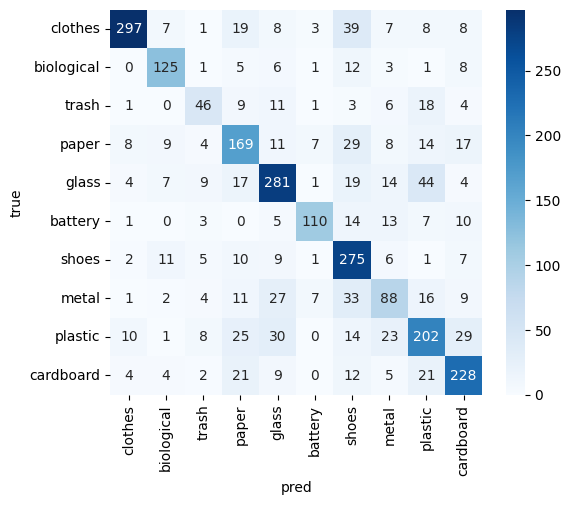

In [18]:
plot_conf_matrix(cm, class_names)

## MobileNetV2

In [5]:
def build_MobileNetV2(learning_rate = 1e-2, momentum = 0.9, beta_2 = 0.99, **kwargs):
    
    normalization_layer = Rescaling(1./255)
    
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    model = tf.keras.models.Sequential([normalization_layer,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(10, activation="softmax")
    ])

    optimizer = Adam(learning_rate=learning_rate, beta_1=momentum, beta_2=beta_2)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model


In [ ]:
which_arch = "mobilenetv2"

param_grid = {"learning_rate": [1e-2, 1e-3],
              "momentum": [0.0, 0.9],
              "beta_2": [0.99, 0.999]}

# X_train, X_test, y_train, y_test
best_params, best_accuracy, result_df  = CNN_GridSearchCV(X_train_full, y_train_labels, param_grid, build_MobileNetV2, 42, 5,n_jobs=1 ,batch_size=batch_size)

pd.DataFrame(result_df).to_csv(root_logdir(which_arch)+"/CV/cv_result.csv")

In [8]:
run_id, run_logdir = get_run_logdir(which_arch, "2")

tensorboard_cb = TensorBoard(run_logdir)
early_stopping = EarlyStopping(patience = 5, monitor = "loss")

model = build_MobileNetV2(**best_params)    
# here we can save the best model
model.fit(X_train_full, y_train_labels, epochs=50, callbacks= [tensorboard_cb, early_stopping])

table_from_history(model.history.history, run_id).to_csv("curves_data/"+which_arch+"/"+run_id+".csv")

save_params(run_logdir, "best_params_custom_model.pkl", best_params)
# best_params = {'learning_rate': 0.01, 'momentum': 0.9, 'n_filters': 32, 'n_neurons': 64}

Epoch 1/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.7552 - loss: 0.7450
Epoch 2/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8647 - loss: 0.4088
Epoch 3/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8915 - loss: 0.3218
Epoch 4/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9118 - loss: 0.2719
Epoch 5/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9242 - loss: 0.2324
Epoch 6/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9355 - loss: 0.2029
Epoch 7/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9432 - loss: 0.1819
Epoch 8/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9511 - loss: 0.1621
Epoch 9/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9558 - loss: 0.1473
Epoch 10/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9612 - loss: 0.1338
Epoch 11/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9636 - loss: 0.1238
Epoch 12/50
334/334 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/st

In [9]:
model.evaluate(X_test_full, y_test_labels)

84/84 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.8453 - loss: 1.0155


[1.0154708623886108, 0.8453183770179749]

In [10]:
y_pred = np.argmax(model.predict(X_test_full), axis = 1)

84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step


In [11]:
cm = compute_classification_metrics(y_test_labels, y_pred, class_names)

              precision    recall  f1-score   support

     clothes       0.96      0.94      0.95       397
  biological       0.92      0.92      0.92       162
       trash       0.77      0.61      0.68        99
       paper       0.78      0.79      0.79       276
       glass       0.84      0.82      0.83       400
     battery       0.87      0.93      0.90       163
       shoes       0.93      0.95      0.94       327
       metal       0.74      0.68      0.71       198
     plastic       0.73      0.78      0.76       342
   cardboard       0.84      0.86      0.85       306

    accuracy                           0.85      2670
   macro avg       0.84      0.83      0.83      2670
weighted avg       0.85      0.85      0.84      2670



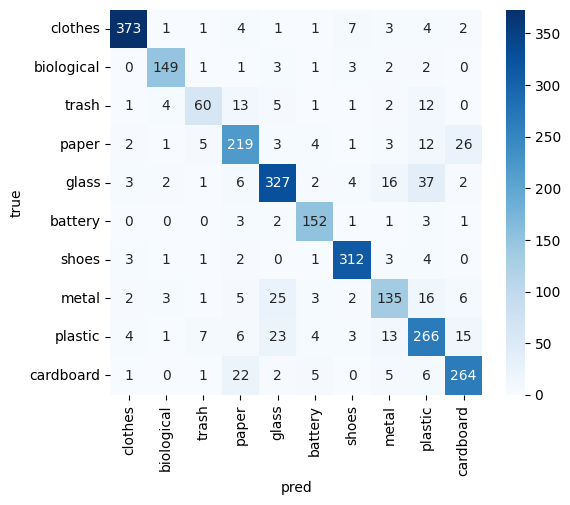

In [13]:
plot_conf_matrix(cm, class_names)